# 13 — Spread Divergence: Window 1 (ESU4 → ESZ4)

**Question:** During the W1 roll window (Sep 12–19 2024), did the back contract (ESZ4) bid-ask spread expand while the front contract (ESU4) bid-ask spread contract? And how did the calendar spread (ESZ4 − ESU4 mid) evolve?

**Design:** Files are loaded one day at a time to avoid OOM. Each file is reduced to summary stats, then discarded before the next load.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import gc
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Volumes/SEAGATE/Databento_Futures'
TICK      = 0.25          # ES tick size in index points
MULT      = 50            # $50 per index point

# Roll days in order: Thu, Fri, Mon-Fri (crossover = Sep 12)
DAYS = [
    '2024-09-12',  # Day 1 — Thu (crossover day)
    '2024-09-13',  # Day 2 — Fri
    '2024-09-15',  # Day 3 — Mon
    '2024-09-16',  # Day 4 — Tue
    '2024-09-17',  # Day 5 — Wed
    '2024-09-18',  # Day 6 — Thu (FOMC)
    '2024-09-19',  # Day 7 — Fri (expiry)
]
DAY_LABELS = ['D1\nThu', 'D2\nFri', 'D3\nMon', 'D4\nTue', 'D5\nWed', 'D6\nFOMC', 'D7\nExp']

# RTH = 13:30–20:00 UTC
RTH_START_MIN = 13 * 60 + 30   # 810
RTH_END_MIN   = 20 * 60         # 1200

COLS = ['ts_event', 'symbol', 'bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00']
print('Config loaded. Days:', DAYS)

Config loaded. Days: ['2024-09-12', '2024-09-13', '2024-09-15', '2024-09-16', '2024-09-17', '2024-09-18', '2024-09-19']


## Part 1 — Bid-Ask Spread per Contract

For each day we load one parquet, split by symbol, compute bid-ask spread stats,
and keep only the summary rows before loading the next file.

In [10]:
ba_records = []   # one dict per (day, symbol, session)

for i, day in enumerate(DAYS):
    path = f'{DATA_DIR}/mbp10_ESU4_ESZ4_2024-09-12_{day}.parquet'
    print(f'Loading {day} ...', end=' ', flush=True)

    df = pd.read_parquet(path, columns=COLS)
    df['ts_event'] = pd.to_datetime(df['ts_event'], utc=True)
    df = df[df['bid_px_00'] > 0].copy()

    df['ba_spread_ticks'] = (df['ask_px_00'] - df['bid_px_00']) / TICK

    # time-of-day in minutes for session filter
    tod = df['ts_event'].dt.hour * 60 + df['ts_event'].dt.minute

    sessions = {
        'ALL': df,
        'RTH': df[(tod >= RTH_START_MIN) & (tod < RTH_END_MIN)],
        'GLOBEX': df[(tod < RTH_START_MIN) | (tod >= RTH_END_MIN)],
    }

    for session, sub in sessions.items():
        for sym in ['ESU4', 'ESZ4']:
            s = sub[sub['symbol'] == sym]['ba_spread_ticks']
            if len(s) == 0:
                continue
            vc = s.value_counts(normalize=True)
            ba_records.append({
                'day':       day,
                'day_idx':   i,
                'symbol':    sym,
                'session':   session,
                'n':         len(s),
                'mean':      s.mean(),
                'median':    s.median(),
                'p25':       s.quantile(0.25),
                'p75':       s.quantile(0.75),
                'pct_1tick': vc.get(1.0, 0.0),
                'pct_2tick': vc.get(2.0, 0.0),
                'pct_3tick': vc.get(3.0, 0.0),
            })

    print(f'  {len(df):,} rows processed')
    del df, sessions
    gc.collect()

ba = pd.DataFrame(ba_records)
print('\nDone. Summary rows:', len(ba))

Loading 2024-09-12 ...   16,538,866 rows processed
Loading 2024-09-13 ...   14,128,605 rows processed
Loading 2024-09-15 ...   220,478 rows processed
Loading 2024-09-16 ...   12,965,159 rows processed
Loading 2024-09-17 ...   18,697,323 rows processed
Loading 2024-09-18 ...   16,449,303 rows processed
Loading 2024-09-19 ...   15,573,742 rows processed

Done. Summary rows: 40


In [11]:
# ── Pivot to clean summary table (RTH only)
rth = ba[ba['session'] == 'RTH'].copy()

pivot = rth.pivot_table(
    index='day', columns='symbol',
    values=['mean', 'median', 'pct_1tick', 'pct_2tick'],
    aggfunc='first'
)
pivot.columns = [f'{v}_{s}' for v, s in pivot.columns]
pivot = pivot.reset_index()

print('=== RTH Bid-Ask Spread Summary (ticks) ===')
fmt = {
    'mean_ESU4':     '{:.3f}',
    'mean_ESZ4':     '{:.3f}',
    'median_ESU4':   '{:.2f}',
    'median_ESZ4':   '{:.2f}',
    'pct_1tick_ESU4':'{:.1%}',
    'pct_1tick_ESZ4':'{:.1%}',
    'pct_2tick_ESU4':'{:.1%}',
    'pct_2tick_ESZ4':'{:.1%}',
}
pivot_fmt = pivot.copy()
for col, formatter in fmt.items():
    if col in pivot_fmt.columns:
        pivot_fmt[col] = pivot_fmt[col].map(lambda x: formatter.format(x) if pd.notna(x) else x)
display(pivot_fmt)

=== RTH Bid-Ask Spread Summary (ticks) ===


,day,mean_ESU4,mean_ESZ4,median_ESU4,median_ESZ4,pct_1tick_ESU4,pct_1tick_ESZ4,pct_2tick_ESU4,pct_2tick_ESZ4
0,2024-09-12,1.042,1.145,1.00,1.00,95.8%,85.6%,4.2%,14.4%
1,2024-09-13,1.035,1.071,1.00,1.00,96.5%,92.9%,3.5%,7.0%
2,2024-09-16,1.051,1.047,1.00,1.00,94.9%,95.3%,5.1%,4.7%
3,2024-09-17,1.079,1.037,1.00,1.00,92.2%,96.3%,7.8%,3.6%
4,2024-09-18,1.238,1.102,1.00,1.00,78.7%,90.4%,19.7%,8.9%
5,2024-09-19,1.083,1.040,1.00,1.00,91.7%,96.0%,8.2%,3.9%


In [12]:
# ── Plain print version for notebooks without Styler display
print(f'{'Day':<12} {'ESU4_mean':>10} {'ESU4_1t%':>10} {'ESZ4_mean':>10} {'ESZ4_1t%':>10} {'ESZ4_2t%':>10}')
print('-' * 65)
for _, row in pivot.iterrows():
    print(f"{row['day'][5:]:<12}"
          f"{row['mean_ESU4']:>10.3f}"
          f"{row['pct_1tick_ESU4']:>10.1%}"
          f"{row['mean_ESZ4']:>10.3f}"
          f"{row['pct_1tick_ESZ4']:>10.1%}"
          f"{row['pct_2tick_ESZ4']:>10.1%}")

Day           ESU4_mean   ESU4_1t%  ESZ4_mean   ESZ4_1t%   ESZ4_2t%
-----------------------------------------------------------------
09-12            1.042     95.8%     1.145     85.6%     14.4%
09-13            1.035     96.5%     1.071     92.9%      7.0%
09-16            1.051     94.9%     1.047     95.3%      4.7%
09-17            1.079     92.2%     1.037     96.3%      3.6%
09-18            1.238     78.7%     1.102     90.4%      8.9%
09-19            1.083     91.7%     1.040     96.0%      3.9%


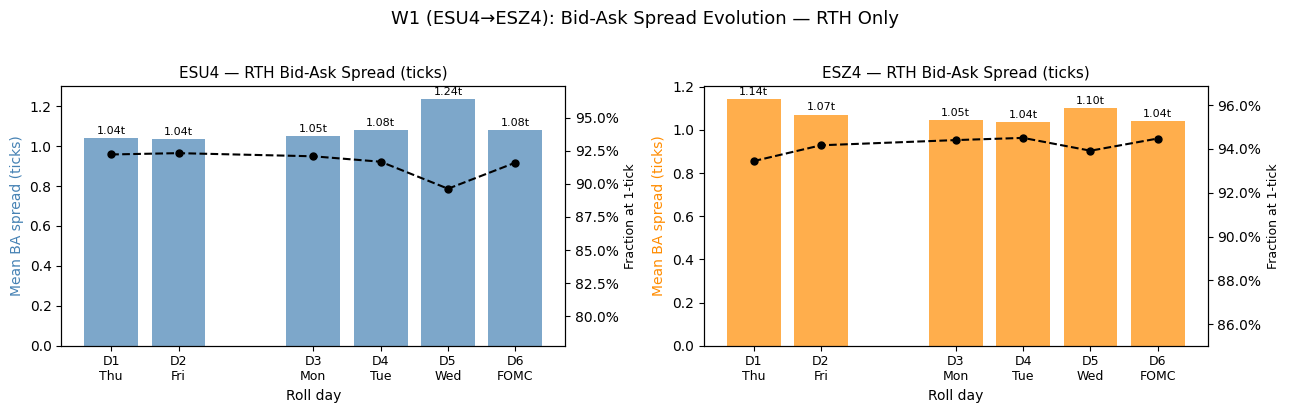

In [13]:
# ── Plot: mean bid-ask spread by day (RTH)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, sym, color in zip(axes, ['ESU4', 'ESZ4'], ['steelblue', 'darkorange']):
    sub = rth[rth['symbol'] == sym].sort_values('day_idx')
    xs  = sub['day_idx'].values

    ax.bar(xs, sub['mean'], color=color, alpha=0.7, label='Mean spread')
    ax.plot(xs, sub['pct_1tick'], 'k--o', markersize=5, label='% at 1-tick')

    ax.set_xticks(xs)
    ax.set_xticklabels(DAY_LABELS[:len(xs)], fontsize=9)
    ax.set_ylabel('Mean BA spread (ticks)', color=color)
    ax2 = ax.twinx()
    ax2.plot(xs, sub['pct_1tick'], 'k--o', markersize=5, alpha=0)
    ax2.set_ylabel('Fraction at 1-tick', fontsize=9)
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(f'{sym} — RTH Bid-Ask Spread (ticks)', fontsize=11)
    ax.set_xlabel('Roll day')

    # annotate bars
    for x, v in zip(xs, sub['mean']):
        ax.text(x, v + 0.01, f'{v:.2f}t', ha='center', va='bottom', fontsize=8)

fig.suptitle('W1 (ESU4→ESZ4): Bid-Ask Spread Evolution — RTH Only', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/figures/13_ba_spread_w1.png', dpi=150, bbox_inches='tight')
plt.show()

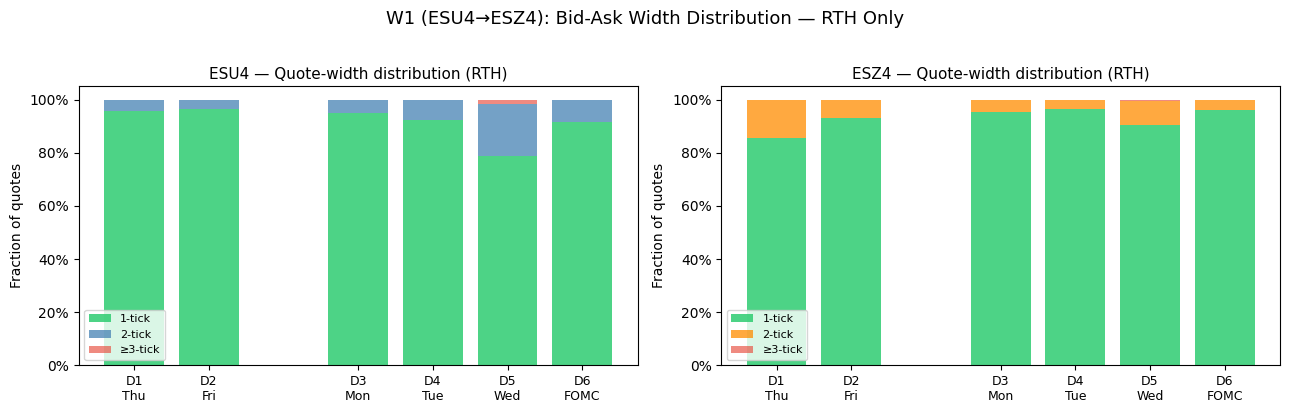

In [14]:
# ── Plot: fraction of time at each spread width (stacked bar)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, sym, color in zip(axes, ['ESU4', 'ESZ4'], ['steelblue', 'darkorange']):
    sub = rth[rth['symbol'] == sym].sort_values('day_idx')
    xs  = sub['day_idx'].values
    p1  = sub['pct_1tick'].values
    p2  = sub['pct_2tick'].values
    p3p = 1 - p1 - p2
    p3p = np.clip(p3p, 0, None)

    ax.bar(xs, p1,  label='1-tick', color='#2ecc71', alpha=0.85)
    ax.bar(xs, p2,  bottom=p1,      label='2-tick', color=color, alpha=0.75)
    ax.bar(xs, p3p, bottom=p1+p2,   label='≥3-tick', color='#e74c3c', alpha=0.65)

    ax.set_xticks(xs)
    ax.set_xticklabels(DAY_LABELS[:len(xs)], fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_ylabel('Fraction of quotes')
    ax.set_title(f'{sym} — Quote-width distribution (RTH)', fontsize=11)
    ax.legend(fontsize=8)

fig.suptitle('W1 (ESU4→ESZ4): Bid-Ask Width Distribution — RTH Only', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/figures/13_ba_width_dist_w1.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 2 — Calendar Spread (ESZ4 − ESU4 mid)

For each day we resample both legs to 1-minute last-mid, then compute:
- `cal_spread` = ESZ4_mid − ESU4_mid  
- `cal_ba_spread` = effective cost of crossing the calendar (ask_Z − bid_U, or bid_Z − ask_U)
- Day-of-roll drift: first vs last hour

In [15]:
cal_records = []   # one dict per (day, minute)

for i, day in enumerate(DAYS):
    path = f'{DATA_DIR}/mbp10_ESU4_ESZ4_2024-09-12_{day}.parquet'
    print(f'Loading {day} ...', end=' ', flush=True)

    df = pd.read_parquet(path, columns=COLS)
    df['ts_event'] = pd.to_datetime(df['ts_event'], utc=True)
    df = df[df['bid_px_00'] > 0].copy()
    df['mid'] = (df['bid_px_00'] + df['ask_px_00']) / 2

    # Resample each symbol to 1-minute snapshots (last mid in each bar)
    def resample_sym(sym):
        s = df[df['symbol'] == sym].set_index('ts_event')
        r = s[['mid', 'bid_px_00', 'ask_px_00']].resample('1min').last().dropna()
        r.columns = [f'{c}_{sym}' for c in r.columns]
        return r

    u = resample_sym('ESU4')
    z = resample_sym('ESZ4')

    # Inner-join on minute bars that have both legs
    both = u.join(z, how='inner')
    both['day'] = day
    both['day_idx'] = i

    # Calendar spread metrics
    both['cal_spread']    = both['mid_ESZ4']     - both['mid_ESU4']
    # Effective bid/ask of the calendar from a buyer's perspective (buy back, sell front)
    both['cal_ask_eff']   = both['ask_px_00_ESZ4'] - both['bid_px_00_ESU4']  # pay ask Z, hit bid U
    both['cal_bid_eff']   = both['bid_px_00_ESZ4'] - both['ask_px_00_ESU4']  # hit bid Z, pay ask U
    both['cal_ba_spread'] = both['cal_ask_eff']  - both['cal_bid_eff']        # effective BA of the calendar
    both['cal_ba_ticks']  = both['cal_ba_spread'] / TICK

    # RTH filter
    tod = both.index.hour * 60 + both.index.minute
    both_rth = both[(tod >= RTH_START_MIN) & (tod < RTH_END_MIN)]

    cal_records.append(both_rth[[
        'day', 'day_idx', 'cal_spread', 'cal_ask_eff', 'cal_bid_eff',
        'cal_ba_spread', 'cal_ba_ticks',
        'mid_ESU4', 'mid_ESZ4'
    ]].copy())

    n = len(both_rth)
    print(f'  {n} RTH 1-min bars')

    del df, u, z, both, both_rth
    gc.collect()

cal = pd.concat(cal_records)
print(f'\nDone. Total 1-min bars: {len(cal):,}')

Loading 2024-09-12 ...   390 RTH 1-min bars
Loading 2024-09-13 ...   390 RTH 1-min bars
Loading 2024-09-15 ...   0 RTH 1-min bars
Loading 2024-09-16 ...   390 RTH 1-min bars
Loading 2024-09-17 ...   390 RTH 1-min bars
Loading 2024-09-18 ...   390 RTH 1-min bars
Loading 2024-09-19 ...   390 RTH 1-min bars

Done. Total 1-min bars: 2,340


In [16]:
# ── Day-level calendar spread summary
cal_daily = cal.groupby(['day_idx', 'day']).agg(
    cal_open  = ('cal_spread', 'first'),
    cal_close = ('cal_spread', 'last'),
    cal_mean  = ('cal_spread', 'mean'),
    cal_std   = ('cal_spread', 'std'),
    cal_min   = ('cal_spread', 'min'),
    cal_max   = ('cal_spread', 'max'),
    cal_ba_mean = ('cal_ba_ticks', 'mean'),
    cal_ba_med  = ('cal_ba_ticks', 'median'),
).reset_index().sort_values('day_idx')

cal_daily['cal_drift'] = cal_daily['cal_close'] - cal_daily['cal_open']
cal_daily['cal_range'] = cal_daily['cal_max']   - cal_daily['cal_min']

print('=== Calendar Spread (ESZ4 - ESU4 mid) by Day — RTH ===')
print(f'{'Day':<12} {'Open':>8} {'Close':>8} {'Drift':>8} {'Range':>8} {'Mean':>8} {'Std':>7} {'BA_tks':>8}')
print('-' * 70)
for _, r in cal_daily.iterrows():
    print(f"{r['day'][5:]:<12}"
          f"{r['cal_open']:>8.2f}"
          f"{r['cal_close']:>8.2f}"
          f"{r['cal_drift']:>+8.2f}"
          f"{r['cal_range']:>8.2f}"
          f"{r['cal_mean']:>8.2f}"
          f"{r['cal_std']:>7.2f}"
          f"{r['cal_ba_mean']:>8.2f}")

=== Calendar Spread (ESZ4 - ESU4 mid) by Day — RTH ===
Day              Open    Close    Drift    Range     Mean     Std   BA_tks
----------------------------------------------------------------------
09-12          60.25   60.25   +0.00    0.75   60.21   0.14    2.24
09-13          60.25   61.25   +1.00    1.00   60.74   0.14    2.13
09-16          61.00   61.25   +0.25    1.25   60.90   0.26    2.15
09-17          61.25   61.25   +0.00    1.38   61.05   0.32    2.15
09-18          61.25   59.50   -1.75    2.25   60.28   0.54    2.31
09-19          60.25   60.50   +0.25    1.00   59.94   0.14    2.17


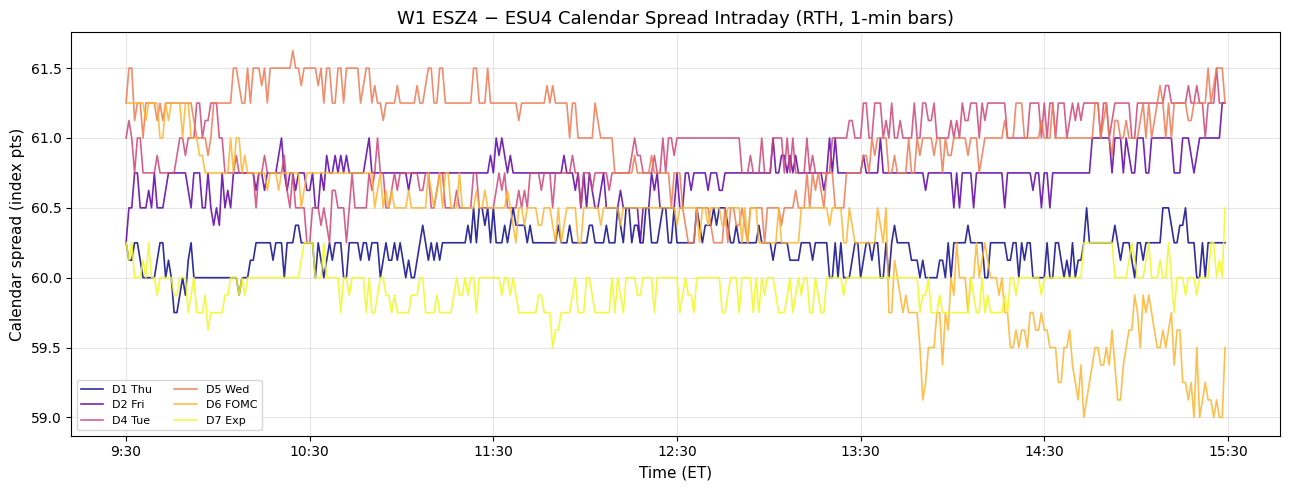

In [17]:
# ── Plot: calendar spread time-series (one line per day, RTH)
fig, ax = plt.subplots(figsize=(13, 5))

cmap = plt.cm.plasma
for i, day in enumerate(DAYS):
    sub = cal[cal['day'] == day].copy()
    if len(sub) == 0:
        continue
    # normalise intraday time to 0-1 for x-axis
    ts_min = sub.index.hour * 60 + sub.index.minute
    ts_norm = (ts_min - RTH_START_MIN) / (RTH_END_MIN - RTH_START_MIN)
    color = cmap(i / (len(DAYS) - 1))
    ax.plot(ts_norm, sub['cal_spread'].values, color=color,
            linewidth=1.2, alpha=0.85, label=DAY_LABELS[i].replace('\n', ' '))

# x-axis: convert back to RTH time labels
tick_positions = np.linspace(0, 1, 7)
tick_labels = ['9:30', '10:30', '11:30', '12:30', '13:30', '14:30', '15:30']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_xlabel('Time (ET)', fontsize=11)
ax.set_ylabel('Calendar spread (index pts)', fontsize=11)
ax.set_title('W1 ESZ4 − ESU4 Calendar Spread Intraday (RTH, 1-min bars)', fontsize=13)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/13_cal_spread_intraday_w1.png', dpi=150, bbox_inches='tight')
plt.show()

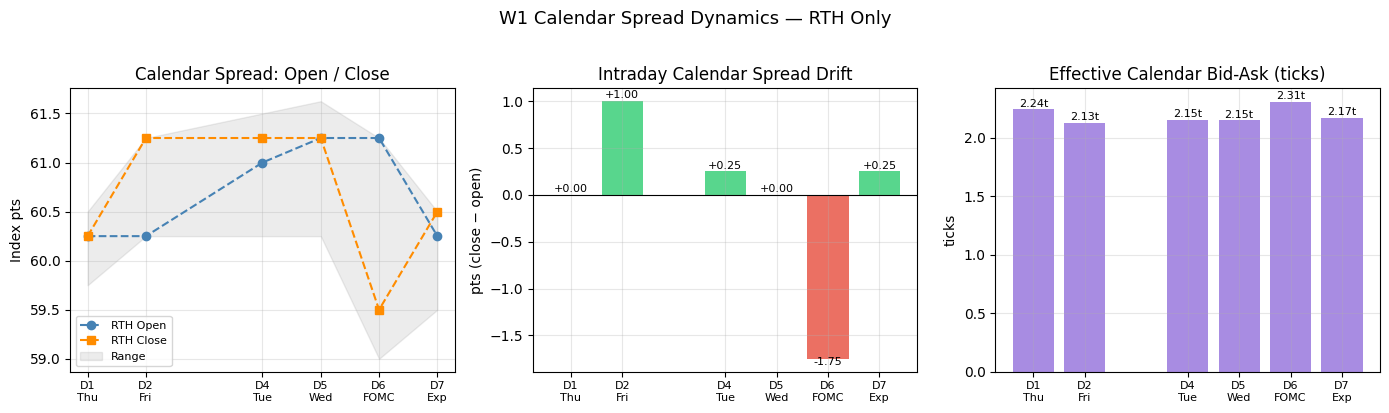

In [18]:
# ── Plot: calendar spread range and drift by day
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

xs = cal_daily['day_idx'].values
xlabels = [DAY_LABELS[i] for i in xs]

# Panel 1: open vs close
axes[0].plot(xs, cal_daily['cal_open'],  'o--', color='steelblue',  label='RTH Open')
axes[0].plot(xs, cal_daily['cal_close'], 's--', color='darkorange', label='RTH Close')
axes[0].fill_between(xs, cal_daily['cal_min'], cal_daily['cal_max'], alpha=0.15, color='grey', label='Range')
axes[0].set_xticks(xs); axes[0].set_xticklabels(xlabels, fontsize=8)
axes[0].set_ylabel('Index pts'); axes[0].set_title('Calendar Spread: Open / Close')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Panel 2: intraday drift
colors_drift = ['#e74c3c' if v < 0 else '#2ecc71' for v in cal_daily['cal_drift']]
axes[1].bar(xs, cal_daily['cal_drift'], color=colors_drift, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(xs); axes[1].set_xticklabels(xlabels, fontsize=8)
axes[1].set_ylabel('pts (close − open)'); axes[1].set_title('Intraday Calendar Spread Drift')
for x, v in zip(xs, cal_daily['cal_drift']):
    axes[1].text(x, v + (0.03 if v >= 0 else -0.07), f'{v:+.2f}', ha='center', fontsize=8)
axes[1].grid(alpha=0.3)

# Panel 3: effective calendar BA spread in ticks
axes[2].bar(xs, cal_daily['cal_ba_mean'], color='mediumpurple', alpha=0.8)
axes[2].set_xticks(xs); axes[2].set_xticklabels(xlabels, fontsize=8)
axes[2].set_ylabel('ticks'); axes[2].set_title('Effective Calendar Bid-Ask (ticks)')
for x, v in zip(xs, cal_daily['cal_ba_mean']):
    axes[2].text(x, v + 0.02, f'{v:.2f}t', ha='center', fontsize=8)
axes[2].grid(alpha=0.3)

fig.suptitle('W1 Calendar Spread Dynamics — RTH Only', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/figures/13_cal_spread_daily_w1.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 3 — Liquidity Migration: Bid Size at Best

Best bid/ask sizes give a direct view of where liquidity is pooling or draining day-over-day.

In [19]:
liq_records = []
SIZE_COLS = ['ts_event', 'symbol', 'bid_sz_00', 'ask_sz_00', 'bid_px_00', 'ask_px_00']

for i, day in enumerate(DAYS):
    path = f'{DATA_DIR}/mbp10_ESU4_ESZ4_2024-09-12_{day}.parquet'
    print(f'Loading {day} ...', end=' ', flush=True)

    df = pd.read_parquet(path, columns=SIZE_COLS)
    df['ts_event'] = pd.to_datetime(df['ts_event'], utc=True)
    df = df[df['bid_px_00'] > 0].copy()

    tod = df['ts_event'].dt.hour * 60 + df['ts_event'].dt.minute
    rth_df = df[(tod >= RTH_START_MIN) & (tod < RTH_END_MIN)]

    for sym in ['ESU4', 'ESZ4']:
        sub = rth_df[rth_df['symbol'] == sym]
        if len(sub) == 0:
            continue
        bid_sz = sub['bid_sz_00']
        ask_sz = sub['ask_sz_00']
        liq_records.append({
            'day':          day,
            'day_idx':      i,
            'symbol':       sym,
            'bid_sz_mean':  bid_sz.mean(),
            'bid_sz_med':   bid_sz.median(),
            'ask_sz_mean':  ask_sz.mean(),
            'ask_sz_med':   ask_sz.median(),
            'n':            len(sub),
        })

    print(f'  ok')
    del df, rth_df
    gc.collect()

liq = pd.DataFrame(liq_records)
print('\nDone.')

Loading 2024-09-12 ...   ok
Loading 2024-09-13 ...   ok
Loading 2024-09-15 ...   ok
Loading 2024-09-16 ...   ok
Loading 2024-09-17 ...   ok
Loading 2024-09-18 ...   ok
Loading 2024-09-19 ...   ok

Done.


In [20]:
# ── Print liquidity migration table
print('=== Median Bid Size at Best — RTH ===')
print(f'{'Day':<12} {'ESU4_bid_med':>14} {'ESZ4_bid_med':>14} {'ratio_Z/U':>12}')
print('-' * 55)
days_seen = liq[liq['symbol']=='ESU4'].sort_values('day_idx')
for _, r in days_seen.iterrows():
    z_row = liq[(liq['day']==r['day']) & (liq['symbol']=='ESZ4')]
    if len(z_row) == 0:
        continue
    z_med = z_row['bid_sz_med'].values[0]
    u_med = r['bid_sz_med']
    ratio = z_med / u_med if u_med > 0 else float('nan')
    print(f"{r['day'][5:]:<12}{u_med:>14.1f}{z_med:>14.1f}{ratio:>12.2f}")

=== Median Bid Size at Best — RTH ===
Day            ESU4_bid_med   ESZ4_bid_med    ratio_Z/U
-------------------------------------------------------
09-12                 29.0           5.0        0.17
09-13                 27.0          13.0        0.48
09-16                 21.0          24.0        1.14
09-17                 13.0          25.0        1.92
09-18                  6.0          12.0        2.00
09-19                 11.0          29.0        2.64


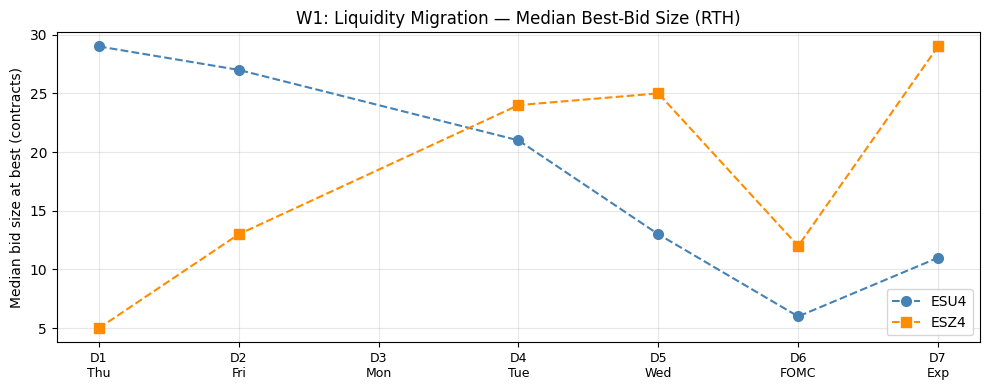

In [21]:
# ── Plot: median bid size at best, both contracts
fig, ax = plt.subplots(figsize=(10, 4))

for sym, color, marker in [('ESU4','steelblue','o'), ('ESZ4','darkorange','s')]:
    sub = liq[liq['symbol']==sym].sort_values('day_idx')
    ax.plot(sub['day_idx'], sub['bid_sz_med'], f'{marker}--',
            color=color, linewidth=1.5, markersize=7, label=sym)

ax.set_xticks(range(len(DAYS)))
ax.set_xticklabels(DAY_LABELS, fontsize=9)
ax.set_ylabel('Median bid size at best (contracts)')
ax.set_title('W1: Liquidity Migration — Median Best-Bid Size (RTH)', fontsize=12)
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/13_liq_migration_w1.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 4 — Summary & Findings

In [22]:
# ── Combined divergence metric: BA spread of back minus BA spread of front
# Positive → back is wider than front, Negative → back is tighter than front

rth_u = ba[(ba['session']=='RTH') & (ba['symbol']=='ESU4')].set_index('day_idx')['mean']
rth_z = ba[(ba['session']=='RTH') & (ba['symbol']=='ESZ4')].set_index('day_idx')['mean']
divergence = (rth_z - rth_u).sort_index()

print('=== Bid-Ask Spread Divergence (ESZ4_mean - ESU4_mean, ticks) ===')
for idx, val in divergence.items():
    day = DAYS[idx]
    direction = 'BACK WIDER' if val > 0 else 'BACK TIGHTER'
    print(f'  D{idx+1} {day[5:]}: {val:+.3f}t  ({direction})')

d1 = divergence.iloc[0]
d7 = divergence.iloc[-1]
print(f'\nD1 divergence: {d1:+.3f}t')
print(f'D7 divergence: {d7:+.3f}t')
print(f'Change D7-D1: {d7-d1:+.3f}t')

print()
print('=== Calendar Spread Level Summary ===')
print(f'D1 RTH open:  {cal_daily["cal_open"].iloc[0]:>.3f} pts')
print(f'D7 RTH close: {cal_daily["cal_close"].iloc[-1]:>.3f} pts')
print(f'Cumulative drift: {cal_daily["cal_close"].iloc[-1] - cal_daily["cal_open"].iloc[0]:>+.3f} pts')
print(f'Daily drift (mean): {cal_daily["cal_drift"].mean():>+.3f} pts/day')
print(f'Daily drift (std):  {cal_daily["cal_drift"].std():>.3f} pts/day')

print()
print('=== Effective Calendar BA Spread ===')
print(f'D1: {cal_daily["cal_ba_mean"].iloc[0]:.2f}t  |  D7: {cal_daily["cal_ba_mean"].iloc[-1]:.2f}t')

=== Bid-Ask Spread Divergence (ESZ4_mean - ESU4_mean, ticks) ===
  D1 09-12: +0.103t  (BACK WIDER)
  D2 09-13: +0.036t  (BACK WIDER)
  D4 09-16: -0.004t  (BACK TIGHTER)
  D5 09-17: -0.042t  (BACK TIGHTER)
  D6 09-18: -0.136t  (BACK TIGHTER)
  D7 09-19: -0.043t  (BACK TIGHTER)

D1 divergence: +0.103t
D7 divergence: -0.043t
Change D7-D1: -0.146t

=== Calendar Spread Level Summary ===
D1 RTH open:  60.250 pts
D7 RTH close: 60.500 pts
Cumulative drift: +0.250 pts
Daily drift (mean): -0.042 pts/day
Daily drift (std):  0.914 pts/day

=== Effective Calendar BA Spread ===
D1: 2.24t  |  D7: 2.17t


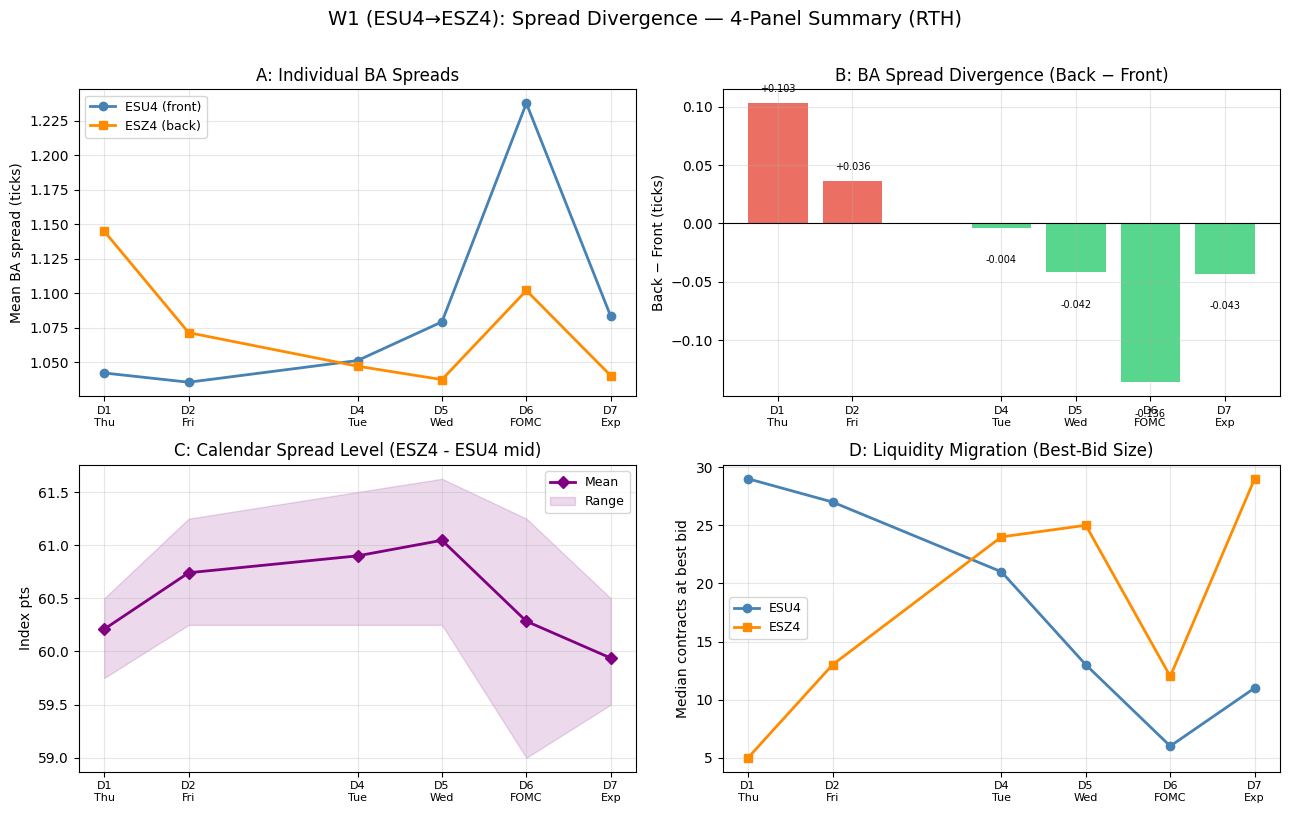

In [24]:
# ── Final 4-panel summary chart
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

xs = sorted(ba.loc[ba['session'] == 'RTH', 'day_idx'].unique().tolist())
day_labels = [DAY_LABELS[i] for i in xs]
u_map = ba[(ba['session'] == 'RTH') & (ba['symbol'] == 'ESU4')].set_index('day_idx')['mean'].to_dict()
z_map = ba[(ba['session'] == 'RTH') & (ba['symbol'] == 'ESZ4')].set_index('day_idx')['mean'].to_dict()

# Panel A: mean BA spread by contract
ax = axes[0, 0]
u_means = [u_map[i] for i in xs]
z_means = [z_map[i] for i in xs]
ax.plot(xs, u_means, 'o-', color='steelblue',  label='ESU4 (front)', linewidth=2)
ax.plot(xs, z_means, 's-', color='darkorange', label='ESZ4 (back)',  linewidth=2)
ax.set_xticks(xs)
ax.set_xticklabels(day_labels, fontsize=8)
ax.set_ylabel('Mean BA spread (ticks)')
ax.set_title('A: Individual BA Spreads')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel B: divergence (back − front)
ax = axes[0, 1]
div_vals = [z - u for z, u in zip(z_means, u_means)]
bar_colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in div_vals]
ax.bar(xs, div_vals, color=bar_colors, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(xs)
ax.set_xticklabels(day_labels, fontsize=8)
ax.set_ylabel('Back − Front (ticks)')
ax.set_title('B: BA Spread Divergence (Back − Front)')
for x, v in zip(xs, div_vals):
    ax.text(x, v + (0.01 if v >= 0 else -0.03), f'{v:+.3f}', ha='center', fontsize=7)
ax.grid(alpha=0.3)

# Panel C: calendar spread level
ax = axes[1, 0]
ax.plot(cal_daily['day_idx'], cal_daily['cal_mean'], 'D-', color='purple', linewidth=2, label='Mean')
ax.fill_between(cal_daily['day_idx'], cal_daily['cal_min'], cal_daily['cal_max'], alpha=0.15, color='purple', label='Range')
ax.set_xticks(xs)
ax.set_xticklabels(day_labels, fontsize=8)
ax.set_ylabel('Index pts')
ax.set_title('C: Calendar Spread Level (ESZ4 - ESU4 mid)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel D: best-bid size migration
ax = axes[1, 1]
for sym, color, marker in [('ESU4', 'steelblue', 'o'), ('ESZ4', 'darkorange', 's')]:
    sub = liq[liq['symbol'] == sym].sort_values('day_idx')
    ax.plot(sub['day_idx'], sub['bid_sz_med'], f'{marker}-', color=color, linewidth=2, label=sym)
ax.set_xticks(xs)
ax.set_xticklabels(day_labels, fontsize=8)
ax.set_ylabel('Median contracts at best bid')
ax.set_title('D: Liquidity Migration (Best-Bid Size)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle('W1 (ESU4→ESZ4): Spread Divergence — 4-Panel Summary (RTH)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/13_summary_4panel_w1.png', dpi=150, bbox_inches='tight')
plt.show()